# Codificación de elementos textuales

## Importación de librerias necesarias

In [68]:
import os
os.getenv('LD_LIBRARY_PATH')

'/usr/lib/x86_64-linux-gnu'

In [69]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [70]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [71]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [72]:
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

In [73]:
import pandas as pd
import tensorflow_hub as hub
from pyspark.ml.functions import array_to_vector

In [74]:
from src.utils.spark import SparkUtils

In [75]:
spark_utils = SparkUtils('encoding')
spark = spark_utils.spark

2025-10-26 16:48:03,102 - SparkCreator - INFO - [SparkUtils] Stopping existing SparkSession...
2025-10-26 16:48:03,579 - SparkCreator - INFO - Starts creating environment
2025-10-26 16:48:03,765 - SparkCreator - INFO - Ends creating environment


In [76]:
REGENERATE_INTERMEDIATE_TABLES = False

In [77]:
from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window

In [78]:
GOLD_SCHEMA = 'gold.premodeling'
GOLD_SCHEMA_ENCODING = 'gold.encoding'
SCHEMA = 'silver.preprocess'

In [79]:
MODULE_URL = "https://tfhub.dev/google/universal-sentence-encoder-large/5"
model = hub.load( MODULE_URL )

2025-10-26 16:48:18,184 - absl - INFO - Fingerprint not found. Saved model loading will continue.
2025-10-26 16:48:18,185 - absl - INFO - path_and_singleprint metric could not be logged. Saved model loading will continue.


## Importar información transformada

In [80]:
main_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = GOLD_SCHEMA
))

In [81]:
meta_items_title_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_text_clean', catalog = GOLD_SCHEMA
))

In [82]:
meta_items_description_sentences_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean', catalog = GOLD_SCHEMA
))

In [83]:
meta_items_features_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean', catalog = GOLD_SCHEMA
))

In [84]:
reviews_indexed_sentences = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed_sentences', catalog = GOLD_SCHEMA
))

In [85]:
reviews_indexed = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed', catalog = SCHEMA
))

## Codificar textos generados en proceso de limpieza de datos

### Definir función genérica para codificación

In [86]:
import random
import uuid
import tensorflow_hub as hub
import numpy as np
from pyspark.sql import Window, functions as F

def embed_batch(texts, batch_size=1024):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        emb = model(batch).numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

def process_to_parquet(
    df, col: str, id_col: str, batch_size: int, tf_batch: int, parquet_path: str,
    overwrite_parquet: bool = False
):
    if not overwrite_parquet:
        df_target = spark.read.parquet(parquet_path)
        print("Original count", df_target.count())

        df = df.alias('A').join(
            df_target.alias('B'),
            on = id_col,
            how = 'left_anti'
        )

    w = Window.orderBy(id_col)
    df_idx = df.withColumn("rn", F.row_number().over(w))
    tmp_table_name = spark_utils.path(
        f"tmp_table_{str(uuid.uuid4()).replace('-', '_')}",
        catalog = GOLD_SCHEMA_ENCODING + '_tmp'
    )
    df_idx.write.format('delta').mode('overwrite').save(tmp_table_name)
    df_idx = spark.read.format('delta').load(tmp_table_name)

    count = df_idx.count()
    print("====Parquets to process=====", count)
    offset = 0
    batch_idx = 0
    while offset < count:
        print("====Processing batch=====", batch_idx, "offset", offset, end = " || ")
        batch_df = (
            df_idx
            .filter((F.col("rn") > offset) & (F.col("rn") <= offset + batch_size))
            .select(id_col, col)
        )
        pdf = batch_df.toPandas()
        texts = pdf[col].fillna("").astype(str).tolist()
        texts = [
            text for text in texts 
                if len(text.split(' ')) <= 30 and len(text) <= 120
        ]
        
        embs = embed_batch(texts, batch_size=tf_batch)
        emb_df = spark.createDataFrame(
            list(zip(pdf[id_col].tolist(), embs.tolist())),
            schema=[id_col, "text_embeddings"]
        )
        mode = "overwrite" if batch_idx == 0 and overwrite_parquet else "append"
        emb_df.write.mode(mode).parquet(parquet_path)
        offset += batch_size
        batch_idx += 1

### Codficación componente de títulos

In [87]:
if REGENERATE_INTERMEDIATE_TABLES:
    process_to_parquet(
        meta_items_title_text_clean,
        col="title",
        id_col="parent_asin",
        batch_size=5000,
        tf_batch=128,
        parquet_path=spark_utils.path(
        'meta_items_title_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [88]:
meta_items_title_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_title_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [89]:
meta_items_title_text_clean_embeddings.show(10)

+-----------+--------------------+
|parent_asin|     text_embeddings|
+-----------+--------------------+
| B0C6FXYC1D|[-0.0557839572429...|
| B0C6FXYV3C|[-0.0305059496313...|
| B0C6FYF46Z|[-0.0091342376545...|
| B0C6FYFZQF|[-0.0911577939987...|
| B0C6FZPDZC|[-0.0128475576639...|
| B0C6FZPQ4G|[-0.0032011696603...|
| B0C6G1GZ4C|[-0.0782524943351...|
| B0C6G29XBT|[-0.0612764135003...|
| B0C6G2BD65|[-0.0633900091052...|
| B0C6G2N4QN|[-0.0483265183866...|
+-----------+--------------------+
only showing top 10 rows



### Codficación componente de descripciones

In [90]:
if REGENERATE_INTERMEDIATE_TABLES:
    process_to_parquet(
        meta_items_description_sentences_text_clean,
        col="description_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [91]:
meta_items_description_sentences_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación componente de características

In [92]:
if REGENERATE_INTERMEDIATE_TABLES:
    process_to_parquet(
        meta_items_features_text_clean,
        col="feature_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_features_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [93]:
meta_items_features_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_features_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación oraciones de reseñas

In [94]:
if REGENERATE_INTERMEDIATE_TABLES:
    process_to_parquet(
        reviews_indexed_sentences,
        col="text_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
            'reviews_indexed_sentences_embeddings', 
            catalog = GOLD_SCHEMA_ENCODING
        ),
        overwrite_parquet=False
    )

In [95]:
reviews_indexed_sentences_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'reviews_indexed_sentences_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [96]:
reviews_indexed_sentences_embeddings.count()

5723302

## Recursos generales ponderación

In [97]:
schema = T.StructType([
    T.StructField("parent_asin", T.StringType()),
    T.StructField("text_embeddings", T.ArrayType(T.DoubleType()))
])

@F.pandas_udf(schema, functionType=F.PandasUDFType.GROUPED_MAP)
def sum_weighted_embeddings(pdf):
    weighted_embeds = np.stack(pdf['weighted_embedding'].values)
    
    summed = weighted_embeds.sum(axis=0)
    
    return pd.DataFrame({
        'parent_asin': [pdf['parent_asin'].iloc[0]],
        'text_embeddings': [summed.tolist()]
    })
    
@F.pandas_udf(schema, functionType=F.PandasUDFType.GROUPED_MAP)
def avg_weighted_embeddings(pdf):
    weighted_embeds = np.stack(pdf['weighted_embedding'].values)
    
    summed = weighted_embeds.mean(axis=0)
    
    return pd.DataFrame({
        'parent_asin': [pdf['parent_asin'].iloc[0]],
        'text_embeddings': [summed.tolist()]
    })

## Promediar embeddings por producto

### Aproximación mediante TFIDF

In [98]:
from src.gold.encoding.tfidf import TfidfEncoder

In [99]:
words_totals = meta_items_title_text_clean.select(F.col("title").alias('text')).union(
    meta_items_description_sentences_text_clean.select(F.col("description_sentence").alias('text'))
).union(
    meta_items_features_text_clean.select(F.col("feature_sentence").alias('text'))
)

In [100]:
TFIDF_PATH = spark_utils.path('tfidf_encoder', catalog = GOLD_SCHEMA_ENCODING)

In [101]:
tf_idf_encoder = TfidfEncoder(
    should_tokenize = True,
    input_col = "text",
    output_col = "text_sentence_tfidf"
)

In [102]:
if REGENERATE_INTERMEDIATE_TABLES:
    tf_idf_encoder.fit(words_totals)
    tf_idf_encoder.save(TFIDF_PATH)

tf_idf_encoder = TfidfEncoder(
    should_tokenize = True,
    input_col = "text",
    output_col = "text_sentence_tfidf"
)

tf_idf_encoder.load(TFIDF_PATH)

In [103]:
@F.udf(returnType=T.DoubleType())
def avg_tfidf(vec):
    return float(vec.values.mean()) if vec.numNonzeros() > 0 else 0.0

In [104]:
meta_items_title_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_title_text_clean.select(
        F.col("parent_asin"),
        F.col("title").alias('text')
    )
).withColumn("avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))).select(
    "parent_asin",
    "avg_tfidf"
)

meta_items_description_sentences_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_description_sentences_text_clean.select(
        F.col("parent_asin"),
        F.col("record_id"),
        F.col("description_sentence").alias('text')
    )
).withColumn(
    "avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))
).select(
    "parent_asin",
    "record_id",
    "avg_tfidf"
)

meta_items_features_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_features_text_clean.select(
        F.col("parent_asin"),
        F.col("record_id"),
        F.col("feature_sentence").alias('text')
    )
).withColumn(
    "avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))
).select(
    "parent_asin",
    "record_id",
    "avg_tfidf"
)

In [105]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_title_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_description_sentences_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_description_sentences_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_features_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_features_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )

meta_items_title_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_sentences_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

In [106]:
window = Window.partitionBy("parent_asin")

meta_items_description_sentences_text_clean_tfidf = meta_items_description_sentences_text_clean_tfidf.withColumn(
    "total_tfidf", F.sum("avg_tfidf").over(window)
).withColumn(
    "tfidf_ratio", F.col("avg_tfidf") / F.col("total_tfidf")
)

meta_items_features_text_clean_tfidf = meta_items_features_text_clean_tfidf.withColumn(
    "total_tfidf", F.sum("avg_tfidf").over(window)
).withColumn(
    "tfidf_ratio", F.col("avg_tfidf") / F.col("total_tfidf")
)

In [107]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_description_sentences_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_description_sentences_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_features_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_features_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
meta_items_description_sentences_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

### Ejecución de ponderación

In [108]:
TITLE_WEIGHT = 0.3
DESCRIPTION_WEIGHT = 0.3
FEATURES_WEIGHT = 0.4

#### Sumarización basada en TFIDF

In [109]:
meta_items_title_embeddings_tfidf = (
    meta_items_title_text_clean_embeddings.select(
        'parent_asin',
        F.transform(
            F.col("text_embeddings"),
            lambda x: x * F.lit(TITLE_WEIGHT)
        ).alias('text_embeddings'),
    )
)

In [110]:
meta_items_description_embeddings_tfidf = (
    meta_items_description_sentences_text_clean_embeddings.alias('A')
        .join(
            meta_items_description_sentences_text_clean_tfidf.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "embedding_array",
            F.col("text_embeddings")
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("embedding_array"), 
            lambda x: x * F.col("tfidf_ratio") * F.lit(DESCRIPTION_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


In [111]:
meta_items_features_embeddings_tfidf = (
    meta_items_features_text_clean_embeddings.alias('A')
        .join(
            meta_items_features_text_clean_tfidf.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "embedding_array",
            F.col("text_embeddings")
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("embedding_array"), 
            lambda x: x * F.col("tfidf_ratio") * F.lit(FEATURES_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [112]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_title_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_description_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_description_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_features_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_features_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

meta_items_title_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))


In [113]:
zero_vector = F.array([F.lit(0.0)] * 512)

In [114]:
meta_items_embeddings_tfidf = (
    main_category_encoded.alias('A')
        .join(
            meta_items_title_embeddings_tfidf.alias('B'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_description_embeddings_tfidf.alias('C'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_features_embeddings_tfidf.alias('D'),
            on='parent_asin',
            how='left'
        )
        .withColumn(
            "title_embed",
            F.when(F.col("B.text_embeddings").isNotNull(), F.col("B.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "desc_embed",
            F.when(F.col("C.text_embeddings").isNotNull(), F.col("C.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "feat_embed",
            F.when(F.col("D.text_embeddings").isNotNull(), F.col("D.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "sum_embedding",
            F.zip_with(
                F.zip_with(F.col("title_embed"), F.col("desc_embed"), lambda x, y: x + y),
                F.col("feat_embed"),
                lambda a, b: a + b
            )
        )
        .select("A.parent_asin", "sum_embedding")
)

In [115]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

#### Sumarización basada en pesos equivalentes

In [116]:
meta_items_title_embeddings_equi = (
    meta_items_title_text_clean_embeddings.select(
        'parent_asin',
        F.transform(
            F.col("text_embeddings"),
            lambda x: x * F.lit(TITLE_WEIGHT)
        ).alias('text_embeddings'),
    )
)

In [117]:
meta_items_description_embeddings_equi = (
    meta_items_description_sentences_text_clean_embeddings.alias('A')
        .join(
            meta_items_description_sentences_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(
                F.col("text_embeddings"), 
                lambda x: x * F.lit(DESCRIPTION_WEIGHT)
            )
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [118]:
meta_items_features_features_equi = (
    meta_items_features_text_clean_embeddings.alias('A')
        .join(
            meta_items_features_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("text_embeddings"), 
            lambda x: x * F.lit(FEATURES_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [119]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_title_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_description_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_description_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_features_features_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_features_features_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

meta_items_title_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_features_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_features_equi', catalog = GOLD_SCHEMA_ENCODING
))


In [120]:
zero_vector = F.array([F.lit(0.0)] * 512)

In [121]:
meta_items_embeddings_equi = (
    main_category_encoded.alias('A')
        .join(
            meta_items_title_embeddings_equi.alias('B'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_description_embeddings_equi.alias('C'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_features_features_equi.alias('D'),
            on='parent_asin',
            how='left'
        )
        .withColumn(
            "title_embed",
            F.when(F.col("B.text_embeddings").isNotNull(), F.col("B.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "desc_embed",
            F.when(F.col("C.text_embeddings").isNotNull(), F.col("C.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "feat_embed",
            F.when(F.col("D.text_embeddings").isNotNull(), F.col("D.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "sum_embedding",
            F.zip_with(
                F.zip_with(F.col("title_embed"), F.col("desc_embed"), lambda x, y: x + y),
                F.col("feat_embed"),
                lambda a, b: a + b
            )
        )
        .select("A.parent_asin", "sum_embedding")
)

In [122]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

## Promediar embeddings por reseña

In [123]:
import numpy as np

In [124]:
@F.pandas_udf("array<float>", functionType=F.PandasUDFType.GROUPED_AGG)
def avg_weighted_embeddings(pdf: pd.DataFrame) -> list:
    return [np.mean(np.vstack(pdf.to_numpy()), axis=0).tolist()]

/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


In [125]:
reviews_embeddings_equi = (
    reviews_indexed_sentences_embeddings.alias('A')
        .join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        )
        .withColumn(
            "weighted_embedding", F.col("text_embeddings")
        )
        .groupBy("review_id") 
        .agg(
            F.aggregate(
                F.collect_list("text_embeddings"),
                F.array_repeat(F.lit(0.0), 512),
                lambda acc, x: F.transform(
                    F.arrays_zip(acc.alias("acc"), x.alias("x")),
                    lambda z: z["acc"] + z["x"]
                )
            ).alias("sum_embeddings"),
            F.count("*").alias("cnt")
        )
        .withColumn(
            "text_embeddings",
            F.transform(
                F.col("sum_embeddings"),
                lambda v: v / F.col("cnt")
            )
        )
        .select("review_id", "text_embeddings")
)

In [126]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

## Reducción de componentes (PCA)

### Reducción de componentes información de productos

In [151]:
from src.gold.training.pca import PCAEncoder

In [142]:
df_vectorized = meta_items_embeddings_equi.withColumn("features", array_to_vector("sum_embedding"))
df_vectorized_tfidf = meta_items_embeddings_tfidf.withColumn("features", array_to_vector("sum_embedding"))

In [152]:
pca_encoder = PCAEncoder(
    id_cols=["parent_asin"],
    input_col="features",
    output_col="pca_features",
    k=150
)

In [153]:
if True:
    pca_encoder.fit(df_vectorized)
    pca_encoder.save(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

pca_encoder = pca_encoder.load(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

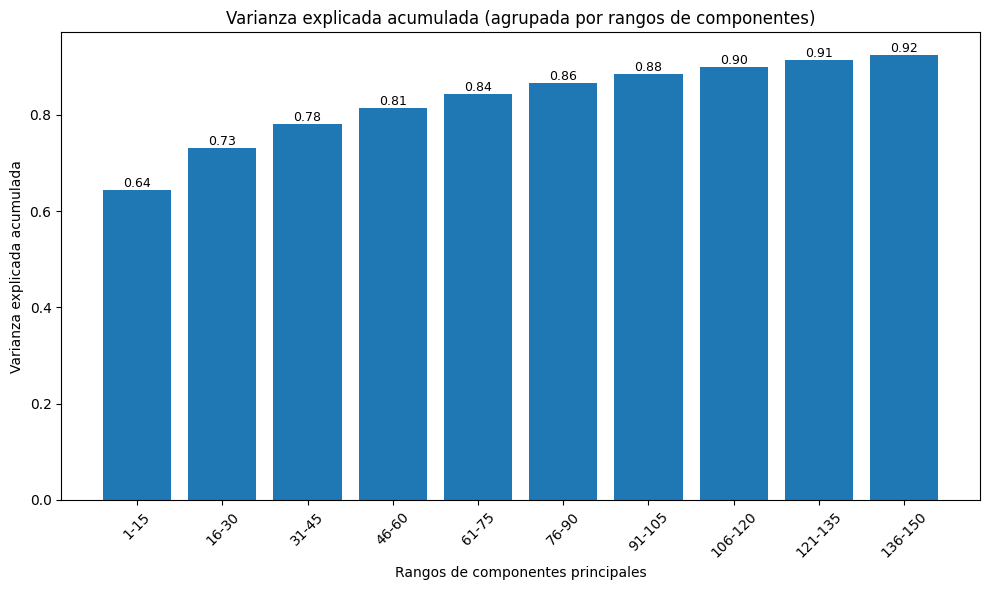

In [154]:
pca_encoder.plot_explained_variance_cumsum_binned()

In [155]:
f"Varianza total explicada: {sum(pca_encoder.model.explainedVariance)}"

'Varianza total explicada: 0.9247417339505526'

In [159]:
if True:
    df_vectorized_pca = pca_encoder.transform(df_vectorized)
    (
        df_vectorized_pca.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca', catalog = GOLD_SCHEMA
))

### Reducción de componentes información de reseñas

In [162]:
from src.gold.training.pca import PCAEncoder

In [163]:
df_reviews_vectorized = reviews_embeddings_equi.withColumn("features", array_to_vector("text_embeddings"))

In [165]:
reviews_pca_encoder = PCAEncoder(
    id_cols=["review_id"],
    input_col="features",
    output_col="pca_features",
    k=250
)

In [166]:
if True:
    reviews_pca_encoder.fit(df_reviews_vectorized)
    reviews_pca_encoder.save(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

reviews_pca_encoder = reviews_pca_encoder.load(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

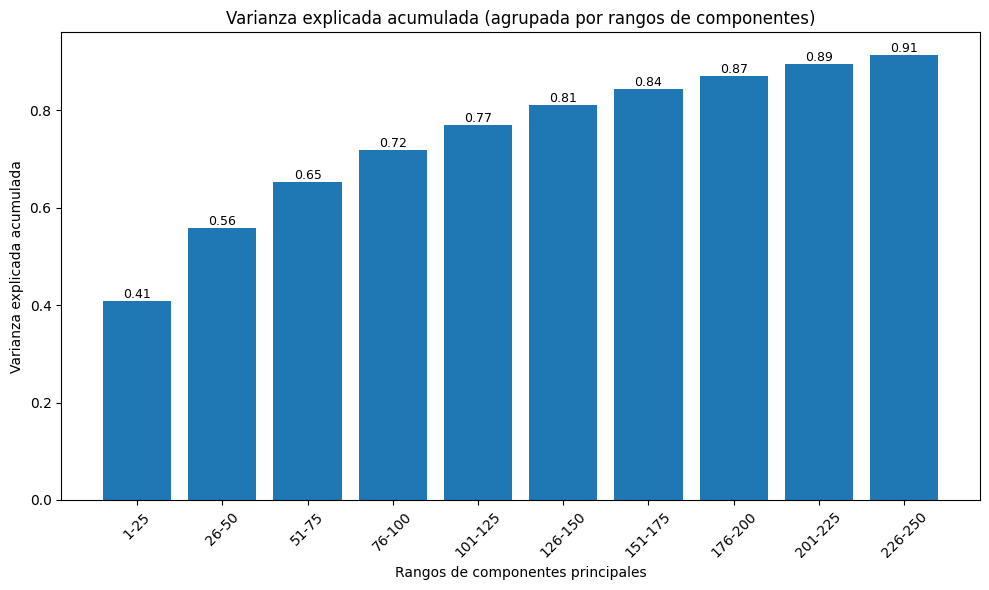

In [167]:
reviews_pca_encoder.plot_explained_variance_cumsum_binned()

In [168]:
sum(reviews_pca_encoder.model.explainedVariance)

0.9141670879530047

In [169]:
if True:
    df_reviews_vectorized_pca = reviews_pca_encoder.transform(df_reviews_vectorized)
    (
        df_reviews_vectorized_pca.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_reviews_vectorized_pca', catalog = GOLD_SCHEMA))
    )

df_reviews_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_reviews_vectorized_pca', catalog = GOLD_SCHEMA
))